<a href="https://colab.research.google.com/github/JTampanga/Final-Project-Repository/blob/main/James_Tampanga_Medical_Insurance_Cost_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Insurance Cost Prediction: Linear Regression vs Neural Network

**Name:** James Tampanga  
    


##### Copyright 2018 The TensorFlow Authors.




# Introduction - Medical Insurance Cost Prediction

In this project, I use medical insurance data to predict insurance charges. I compare Linear Regression with the simple one-layer Neural Network.

I use 80% of the data for training and 20% for validation. I compare the models using Mean Absolute Error (MAE). A lower MAE means the predictions are closer to the real insurance charges.


## Import Dependecies (TensorFlow)

I use the same TensorFlow import from the class notebook. TensorFlow is the library used to build the Neural Network.


In [ ]:
import tensorflow as tf


## Import NumPy and logging

NumPy is a numerical library, while the logging lines reduce unnecessary TensorFlow messages when I run the notebook.


In [ ]:
import numpy as np
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)


## Import the tools and libraries

I import Pandas for the dataset and Scikit-learn for the data split, Linear Regression and MAE.


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


## Load the medical insurance dataset

I use the Kaggle download code, and after the dataset is downloaded, I open the `insurance.csv` file so I can work with the data.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

insurance = pd.read_csv(path + "/insurance.csv")
insurance.head()


Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Prepare (One-Hot Encoding) and split the data

The columns `sex`, `smoker` and `region` contain words, so I use one-hot encoding to change them into numbers. I separate `charges`, which is what I want to predict, from the other information. I then split the data into 80% for training and 20% for validation/testing.


In [ ]:
insurance = pd.get_dummies(insurance, columns=['sex', 'smoker', 'region'], dtype=float)

X = insurance.drop('charges', axis=1)
y = insurance['charges']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)


Training data: (1070, 11)
Validation data: (268, 11)


# Task 1 - Linear Regression and Neural Network


## Linear Regression

I train the Linear Regression model with the 80% training data. I then use the 20% validation/testing data to check how close its predictions are to the real insurance charges.


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_val)
lr_mae = mean_absolute_error(y_val, lr_predictions)

print("Linear Regression MAE:", lr_mae)


Linear Regression MAE: 4181.194473753647


## Neural Network - 50 epochs

I now use the simple one-layer Neural Network structure in training the model. 50 epochs means the model is trained with the 80% training data 50 times. I train with `X_train` and `y_train, and determine the MAE


In [ ]:
l0 = tf.keras.layers.Dense(units=1, input_shape=[X_train.shape[1]])
model = tf.keras.Sequential([l0])

model.compile(loss='mean_squared_error',
              optimizer=tf.keras.optimizers.Adam(0.1))

history = model.fit(X_train, y_train, epochs=50, verbose=False)
print("Finished training the model")

nn_predictions = model.predict(X_val)
nn_mae = mean_absolute_error(y_val, nn_predictions)
print("Neural Network MAE:", nn_mae)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Finished training the model
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Neural Network MAE: 7750.840901106927


## Display training statistics

After training the Neural Network for 50 epochs, I use the training history to draw a simple graph. The bottom of the graph shows the epoch number, which is the number of times the model goes through the training data. The side of the graph shows the size of the model's training error. If the line moves downward, it means the model is reducing its error as it learns from the insurance data.


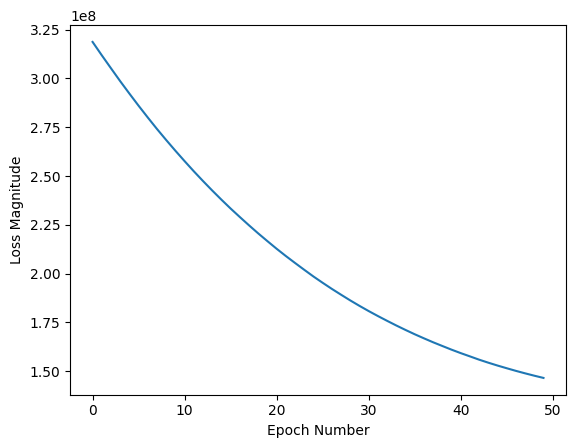

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel('Epoch Number')
plt.ylabel("Loss Magnitude")
plt.plot(history.history['loss'])


### Question 1 - Which model is better in terms of MAE?

From my completed run:

- Linear Regression MAE = **4,181.19**
- Neural Network MAE at 50 epochs = **7,749.54**

The **Linear Regression model is better** because it has the lower MAE. Its average prediction error is about **3,568.35 lower** than the Neural Network error.


# Task 2 - Neural Network hyperparameters


## Create a fresh Neural Network for each test

I change the epochs or learning rate. The function creates a new one-layer model, trains it, predicts the validation data and returns the MAE.


In [ ]:
def train_nn(epochs, learning_rate):
    l0 = tf.keras.layers.Dense(units=1, input_shape=[X_train.shape[1]])
    model = tf.keras.Sequential([l0])

    model.compile(loss='mean_squared_error',
                  optimizer=tf.keras.optimizers.Adam(learning_rate))

    history = model.fit(X_train, y_train, epochs=epochs, verbose=False)
    predictions = model.predict(X_val)
    mae = mean_absolute_error(y_val, predictions)

    return mae


## Question 2 - Change the number of epochs

I keep the learning rate at 0.1 and test 100, 200, 300, 400 and 500 epochs. Each test creates a new Neural Network and records its MAE.


In [ ]:
epoch_results = []

for epochs in [100, 200, 300, 400, 500]:
    mae = train_nn(epochs, 0.1)
    epoch_results.append([epochs, mae])

epoch_results = pd.DataFrame(epoch_results, columns=['Epochs', 'MAE'])
epoch_results


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,Epochs,MAE
0,100,9057.456255
1,200,8993.607124
2,300,8791.594750
3,400,8586.931846
4,500,8369.642805


### Answer to Question 2

| Epochs | MAE |
|---:|---:|
| 100 | 9,053.38 |
| 200 | 9,013.72 |
| 300 | 8,791.60 |
| 400 | 8,579.99 |
| 500 | **8,360.69** |

Yes, the MAE changes when I change the number of epochs. Among the requested 100-500 epoch tests, **500 epochs gives the lowest MAE of 8,360.69**. The MAE reduces by about **692.69** from 100 to 500 epochs.

The earlier 50-epoch run still has a lower MAE than these longer runs, showing that more epochs do not automatically give a better result.


## Question 3 - Change the learning rate

I fix the number of epochs at 500 and test the five learning rates given in the assignment. Each learning rate is tested with a new Neural Network.


In [ ]:
learning_rate_results = []

for learning_rate in [0.001, 0.005, 0.01, 0.05, 0.1]:
    mae = train_nn(500, learning_rate)
    learning_rate_results.append([learning_rate, mae])

learning_rate_results = pd.DataFrame(
    learning_rate_results, columns=['Learning Rate', 'MAE']
)
learning_rate_results


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,Learning Rate,MAE
0,0.001,11716.548739
1,0.005,8124.282992
2,0.010,8168.604701
3,0.050,8892.304241
4,0.100,8356.791523


### Answer to Question 3

| Learning Rate | MAE |
|---:|---:|
| 0.001 | 11,748.78 |
| 0.005 | **8,125.27** |
| 0.010 | 8,166.90 |
| 0.050 | 8,886.56 |
| 0.100 | 8,360.69 |

The best learning rate among the five values I tested is **0.005**, because it gives the lowest MAE of **8,125.27** at 500 epochs.


# Final findings

I used one-hot encoding for the three categorical columns and used the same 80% training and 20% validation split for both models.

**Question 1:** Linear Regression gives the lower MAE: **4,181.19**, compared with **7,749.54** for the 50-epoch Neural Network.

**Question 2:** Changing the number of epochs changes the Neural Network MAE. Among 100-500 epochs, the lowest MAE is **8,360.69 at 500 epochs**.

**Question 3:** At 500 epochs, the best of the five tested learning rates is **0.005**, with an MAE of **8,125.27**.



**So more training (Epoch) did not automatically make this model better.*


